# Phase 2 → Lesson 3: Logistic Regression
What is Logistic Regression?

Linear Regression predicts numbers → "what will the salary be?"

Logistic Regression predicts categories → "will this student pass or fail?"

Despite having "Regression" in the name — it's actually a classification algorithm. It predicts which class/category something belongs to.

Real world examples:

Email → Spam or Not Spam?
Patient → Has disease or Doesn't?
Student → Pass or Fail?
Transaction → Fraud or Legitimate?


How Does it Work?

Linear Regression outputs any number: 27, 85, 1000, -5

Logistic Regression squishes output between 0 and 1 using the Sigmoid function:

`σ(x) = 1 / (1 + e^(-x))`

output meaning : 

`0.0 - 0.5  → Class 0 (Fail, No, Not Spam)
0.5 - 1.0  → Class 1 (Pass, Yes, Spam) `

Think of it like a probability — 0.85 means 85% chance of Class 1.

***Concept 1 — Your First Classification Model***

Line by line:

LogisticRegression() → classification model, not regression!

y = df['Passed'] → label is now 0 or 1, not a number

model.predict() → returns class (0 or 1)

model.predict_proba() → returns probability for each class

accuracy_score() → percentage of correct predictions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Step 1 — Dataset
data = {
    'Hours':   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Passed':  [0, 0, 0, 0, 1, 1, 1, 1, 1,  1]}
df=pd.DataFrame(data)
print(df)
print(df.describe())

#step 2 , featurized and labeled
x=df[['Hours']]
y=df['Passed']

#step 3 split train and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

#step 4 train model
model=LogisticRegression()
model.fit(x_train,y_train)


print(f'actual data x train \n{x_train} \n before prediction and testing y train : \n{y_train}\n')
#step 5 test model
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)
print(f'actual data y test \n{y_test} \n after prediction tested y_pred gonna match with y test: \n{y_pred}\n')
# print(y_pred)
# print(y_prob)

#step 6 evaluate
print(f'Actual:      {list(y_test)}')
print(f'Predicted:   {list(y_pred)}')
print(f'Probability:\n {y_prob}')
print(f'Accuracy:    {accuracy_score(y_test, y_pred):.2f}')

#Classification report
print(classification_report(y_test, y_pred))

#STEP 0,1 T0 PASS/FAIL FOR BETTER UNDERSTANDING
y_pred = pd.Series(y_pred).map({0: 'Fail', 1: 'Pass'})
print('After mapping for better understanding \n',y_pred)

# Output looks like:
# [[0.006, 0.994],   ← 0.6% chance class 0 (Fail), 99.4% chance class 1 (Pass) -> (9 Hours studied)
#  [0.938, 0.062]]   ← 93.8% chance class 0 (Fail), 6.2% chance class 1 (Pass) -> (2 Hours studied)

# Column 0 = probability of Fail (Class 0)
# Column 1 = probability of Pass (Class 1)


   Hours  Passed
0      1       0
1      2       0
2      3       0
3      4       0
4      5       1
5      6       1
6      7       1
7      8       1
8      9       1
9     10       1
          Hours     Passed
count  10.00000  10.000000
mean    5.50000   0.600000
std     3.02765   0.516398
min     1.00000   0.000000
25%     3.25000   0.000000
50%     5.50000   1.000000
75%     7.75000   1.000000
max    10.00000   1.000000
actual data x train 
   Hours
5      6
0      1
7      8
2      3
9     10
4      5
3      4
6      7 
 before prediction and testing y train : 
5    1
0    0
7    1
2    0
9    1
4    1
3    0
6    1
Name: Passed, dtype: int64

actual data y test 
8    1
1    0
Name: Passed, dtype: int64 
 after prediction tested y_pred gonna match with y test: 
[1 0]

Actual:      [1, 0]
Predicted:   [np.int64(1), np.int64(0)]
Probability:
 [[0.0060152  0.9939848 ]
 [0.93844742 0.06155258]]
Accuracy:    1.00
              precision    recall  f1-score   support

           0    

# Visualizing the Sigmoid Curve

Line by line:

np.linspace(-6, 6, 100) → 100 evenly spaced points from -6 to 6 , equal distanve

1 / (1 + np.exp(-x)) → sigmoid formula

axhline(y=0.5) → horizontal line at 0.5 = decision boundary

Above 0.5 → Class 1, Below 0.5 → Class 0

 # Practice Set  — Try These

 Exercise 1: Build a complete Logistic Regression model. Print actual vs predicted values.

Exercise 2: Print the probability scores for test data. Which student has highest pass probability?

Exercise 3: Print the classification report. What is your accuracy?

Exercise 4: Plot the sigmoid curve. Add proper title and labels.

Exercise 5: Predict whether a student who studied 3.5 hours will pass or fail. Print both the class prediction and the probability.

Exercise 6 (thinking): Why is accuracy not always the best metric for classification? Give a real world example where accuracy would be misleading

    StudyHours  Passed
0            1       0
1            2       0
2            2       0
3            3       0
4            4       0
5            4       1
6            5       1
7            6       1
8            7       1
9            8       1
10           9       1
11          10       1
actual data x train 
    StudyHours
8            7
5            4
2            2
1            2
11          10
4            4
7            6
3            3
6            5
before prediction and testing y train : 
8     1
5     1
2     0
1     0
11    1
4     0
7     1
3     0
6     1
Name: Passed, dtype: int64

actual data y test 
10    1
9     1
0     0
Name: Passed, dtype: int64
after prediction tested y_pred gonna match with y test: 
[1 1 0]

0    1
1    1
2    0
dtype: int64
0    Pass
1    Pass
2    Fail
dtype: object
probality for test data 
[[0.00351174 0.99648826]
 [0.01089964 0.98910036]
 [0.96989092 0.03010908]]

(3, 2)
Student 1  probability of fail :  0.003511735733846% and pass : 0

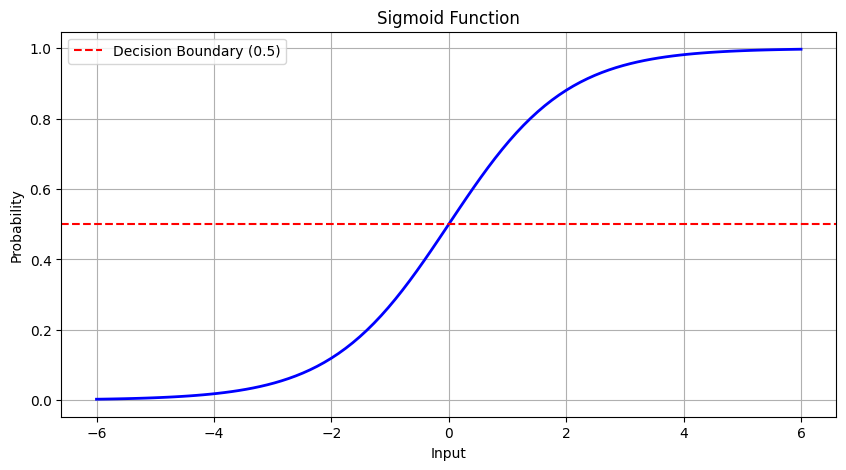

    StudyHours  Passed
0          1.0     0.0
1          2.0     0.0
2          2.0     0.0
3          3.0     0.0
4          4.0     0.0
5          4.0     1.0
6          5.0     1.0
7          6.0     1.0
8          7.0     1.0
9          8.0     1.0
10         9.0     1.0
11        10.0     1.0
12         3.5     NaN
<class 'numpy.ndarray'>
after reshaping : 
 [[3.5]]
(1,)
x1 after convertig to df    StudyHours
0         3.5
(1, 1)
the new predicted value : [0]
the shape : (1, 2),<class 'numpy.ndarray'>
Student   probability of fail :  0.6507200264791215% and pass : 0.3492799735208784%


In [2]:
from scipy.special import xlog1py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

data = {
    'StudyHours': [1, 2, 2, 3, 4, 4, 5, 6, 7, 8, 9, 10],
    'Passed':     [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,  1]}
df=pd.DataFrame(data)
print(df)

x=df[['StudyHours']]
y=df['Passed']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print(f'actual data x train \n{x_train}\nbefore prediction and testing y train : \n{y_train}\n')

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)

print(f'actual data y test \n{y_test}\nafter prediction tested y_pred gonna match with y test: \n{y_pred}\n')
y_pred=pd.Series(y_pred)
print(y_pred)
y_p=pd.Series(y_pred).map({0:'Fail',1:'Pass'})
print(y_p)

print(f'probality for test data \n{y_prob}\n')
print(y_prob.shape)
pass_list=np.array([])
for i,row in enumerate(y_prob,start=1):
      print(f"Student {i}  probability of fail :  {row[0]}% and pass : {row[1]}%")
      pass_list=np.append(pass_list,row[1])

print('the probability of pass student',pass_list)
print(f'The  highest pass probability of student {np.argmax(pass_list)+1} is {np.max(pass_list)}')

print(f'The classification report is : \n{classification_report(y_test,y_pred)}\n')
print(f'The accuracy is : {accuracy_score(y_test,y_pred)}\n')

# Plot sigmoid curve
x_range = np.linspace(-6, 6, 100)
sigmoid = 1 / (1 + np.exp(-x_range))

plt.figure(figsize=(10, 5))
plt.plot(x_range, sigmoid, color='blue', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.title('Sigmoid Function')
plt.xlabel('Input')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

#Predicting after training model with new data values
df.loc[12,'StudyHours']=3.5
print(df)
x1=np.array([3.5])
print(type(x1))
print(f'after reshaping : \n {x1.reshape(-1,1)}')
print(x1.shape)
# Instead of:
# x1 = np.array([3.5]).reshape(-1, 1) / because u will get np.array label warning so convert into dataframe
# Use:
x1 = pd.DataFrame({'StudyHours': [3.5]})
print('x1 after convertig to df',x1)
print(x1.shape)
new=model.predict(x1)  # no warning!
# new=model.predict(x1.reshape(-1,1))
new_prob=model.predict_proba(x1)
print(f'the new predicted value : {new}')
print(f'the shape : {new_prob.shape},{type(new_prob)}')
print(f"Student   probability of fail :  {new_prob[0][0]}% and pass : {new_prob[0][1]}%")
df.loc[12,'Passed']=new

# print(f'The classification report is : \n{classification_report(x1,new)}\n') i tried but giving me errror
#excercise 6: because it can be misleading ,it calculate overall correct prediction , it never see how much 
#i catched correct predictions and  how much i missed like recall and precision do.